# Credit Card Approval Prediction using Machine Learning

### Project Overview

This project predicts whether a credit card application is likely to be approved using Machine Learning techniques. The model is trained on historical applicant and credit records and deployed as a Flask web application for real-time prediction.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Flask
- HTML & CSS
- Joblib

## Import Required Libraries

The following libraries are imported for data manipulation, visualization, machine learning model development, evaluation, and model persistence.

In [1]:
# ===========================
# Ignore Warnings
# ===========================

import warnings
warnings.filterwarnings("ignore")

# ===========================
# Data Manipulation
# ===========================

import numpy as np
import pandas as pd

# ===========================
# Data Visualization
# ===========================

import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# Machine Learning
# ===========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# ===========================
# Model Evaluation
# ===========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ===========================
# Model Saving
# ===========================

import joblib

import imblearn

## Load the Dataset

The required datasets are loaded into Pandas DataFrames for further preprocessing and analysis.

- **application_record.csv** contains applicant information.
- **credit_record.csv** contains the corresponding credit history.

In [2]:
# Load the datasets

application = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

In [3]:
# Display dataset dimensions

print("Application Record Shape :", application.shape)
print("Credit Record Shape      :", credit.shape)

Application Record Shape : (438557, 18)
Credit Record Shape      : (1048575, 3)


In [4]:
# Display the first five records

application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## Explore the Dataset

Before preprocessing, it is important to understand the structure, data types, missing values, and statistical summary of both datasets.

In [6]:
# Display basic information about the application dataset

application.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [7]:
# Display basic information about the credit dataset

credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [8]:
# Statistical summary of numerical columns

application.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [9]:
# Missing values in application dataset

application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [10]:
# Missing values in credit dataset

credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [11]:
# Number of duplicate rows

print("Duplicate rows in Application Dataset :", application.duplicated().sum())
print("Duplicate rows in Credit Dataset      :", credit.duplicated().sum())

Duplicate rows in Application Dataset : 0
Duplicate rows in Credit Dataset      : 0


## Data Cleaning and Preprocessing

The datasets are cleaned and transformed before model training. This includes preparing the target variable, merging the datasets, handling missing values, and selecting relevant features.

In [12]:
# Create the target variable from the credit record dataset

credit["TARGET"] = credit["STATUS"].apply(lambda x: 0 if x in ["1","2","3","4","5"] else 1)
target = credit.groupby("ID")["TARGET"].min()

credit.head()

,ID,MONTHS_BALANCE,STATUS,TARGET
0,5001711,0,X,1
1,5001711,-1,0,1
2,5001711,-2,0,1
3,5001711,-3,0,1
4,5001712,0,C,1


In [13]:
# Aggregate the target for each customer

credit = (
    credit
        .groupby("ID")["TARGET"]
        .min()
        .reset_index()
)

credit.head()

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1


In [50]:
# Merge application and credit datasets

df = application.merge(
    credit,
    on="ID",
    how="inner"
)

print(f"Merged Dataset Shape: {df.shape}")

df.head()

Merged Dataset Shape: (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1


In [51]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].fillna(
    df["DAYS_EMPLOYED"].median()
)

In [15]:
# Remove duplicate records

df.drop_duplicates(inplace=True)

print(f"Dataset Shape after Removing Duplicates: {df.shape}")

Dataset Shape after Removing Duplicates: (36457, 19)


In [16]:
# Fill missing values in Occupation Type

df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Unknown")

# Check remaining missing values

df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64

In [17]:
# Remove unnecessary columns

columns_to_drop = ["ID"]

df.drop(
    columns=columns_to_drop,
    inplace=True
)

In [18]:
# Display the final dataset columns

print("Final Features:")

df.columns

Final Features:


Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET'],
      dtype='str')

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of important features, identify trends, and observe relationships within the dataset before preprocessing and model training.

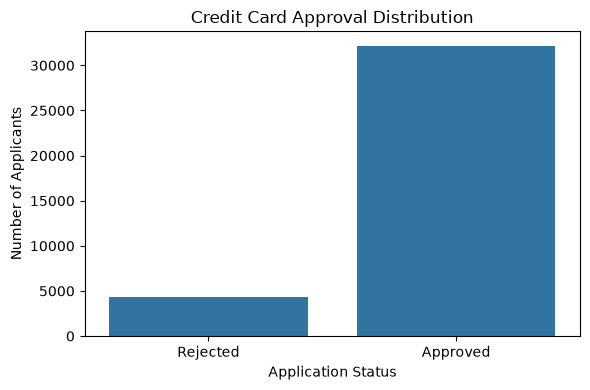

In [19]:
# Distribution of credit card approval status

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="TARGET"
)

# Rename class labels
ax.set_xticklabels(["Rejected", "Approved"])

plt.title("Credit Card Approval Distribution")
plt.xlabel("Application Status")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

**Observation**

The dataset is imbalanced, with approved applicants significantly outnumbering rejected applicants. To overcome this imbalance, SMOTE was applied only to the training dataset before training the Random Forest Classifier, allowing the model to learn both classes more effectively.

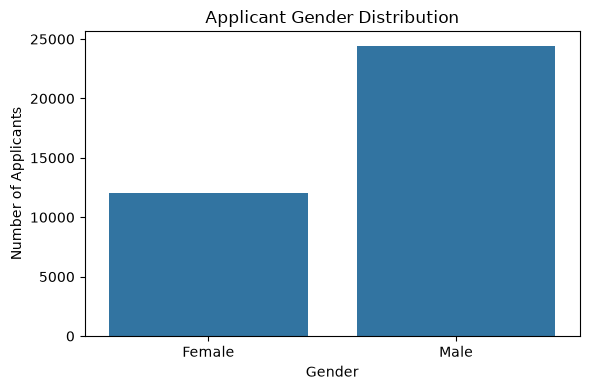

In [20]:
# Visualize the distribution of applicants by gender

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="CODE_GENDER"
)

# Rename gender labels
ax.set_xticklabels(["Female", "Male"])

plt.title("Applicant Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

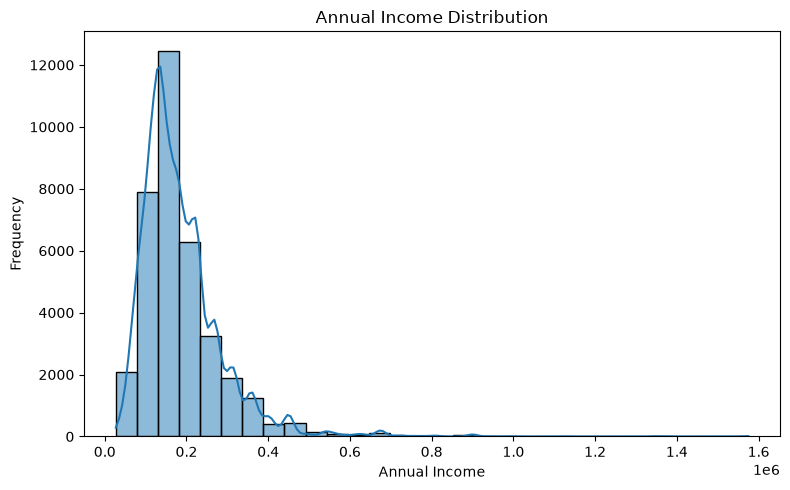

In [21]:
# Visualize the annual income distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=30,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

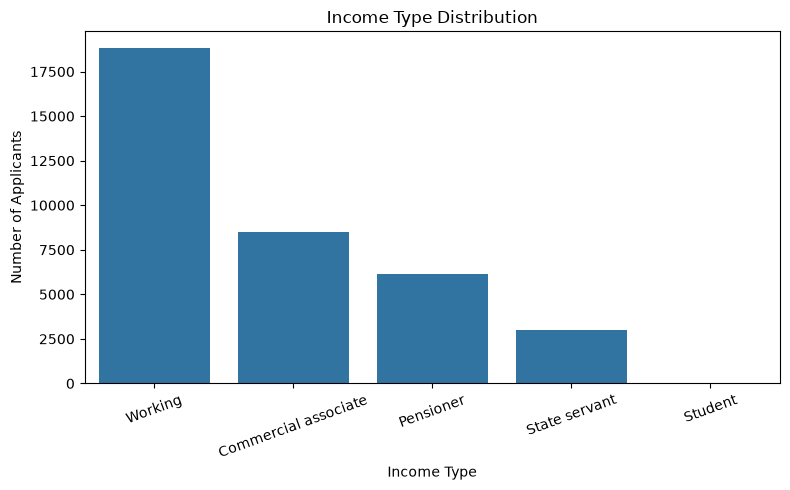

In [22]:
# Distribution of income types

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="NAME_INCOME_TYPE"
)

plt.title("Income Type Distribution")
plt.xlabel("Income Type")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

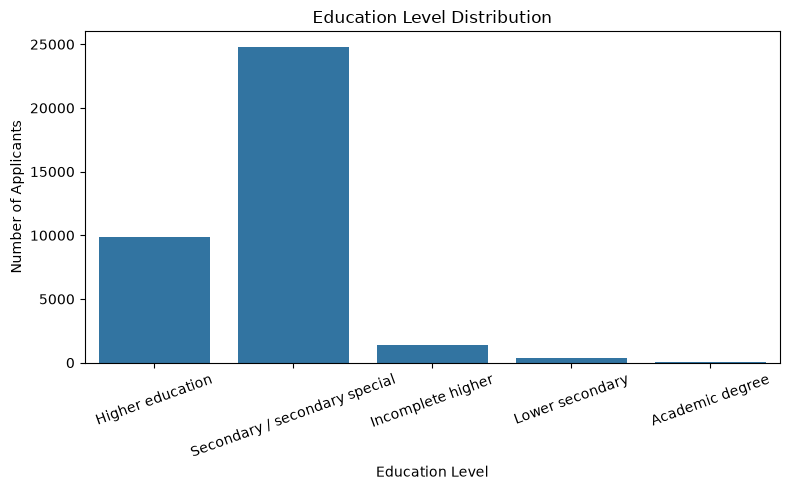

In [23]:
# Distribution of education levels

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="NAME_EDUCATION_TYPE"
)

plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

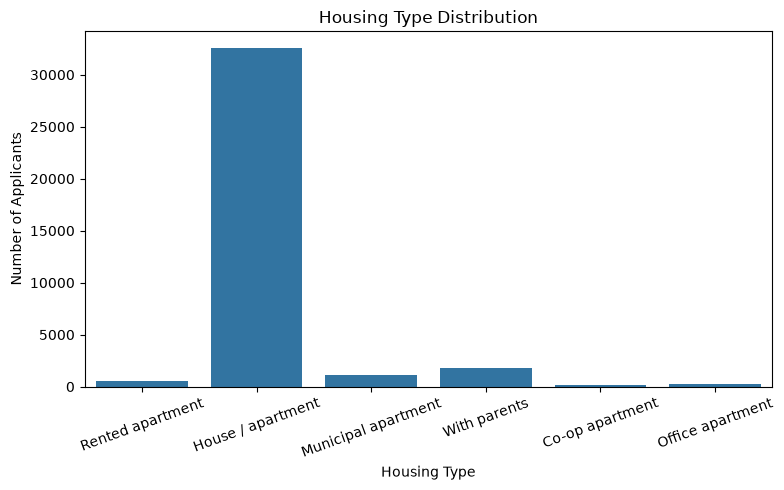

In [24]:
# Distribution of housing types

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="NAME_HOUSING_TYPE"
)

plt.title("Housing Type Distribution")
plt.xlabel("Housing Type")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

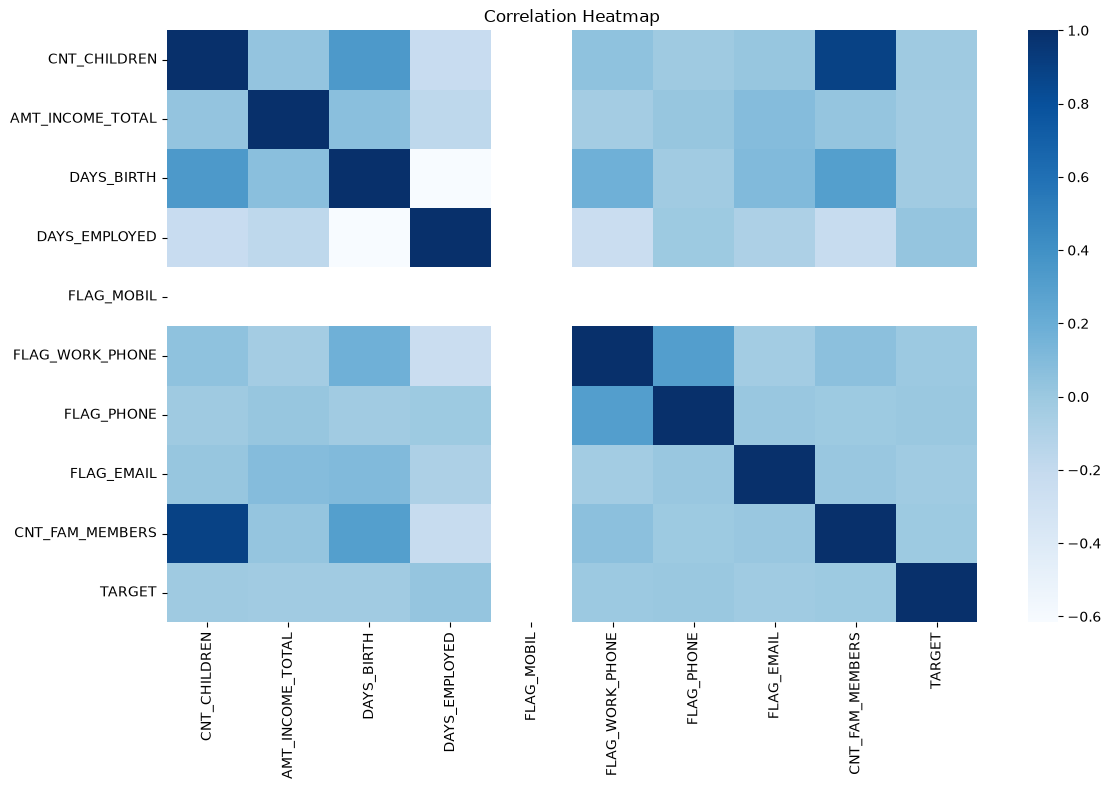

In [25]:
# Visualize the correlation between numerical features

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="Blues",
    annot=False
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

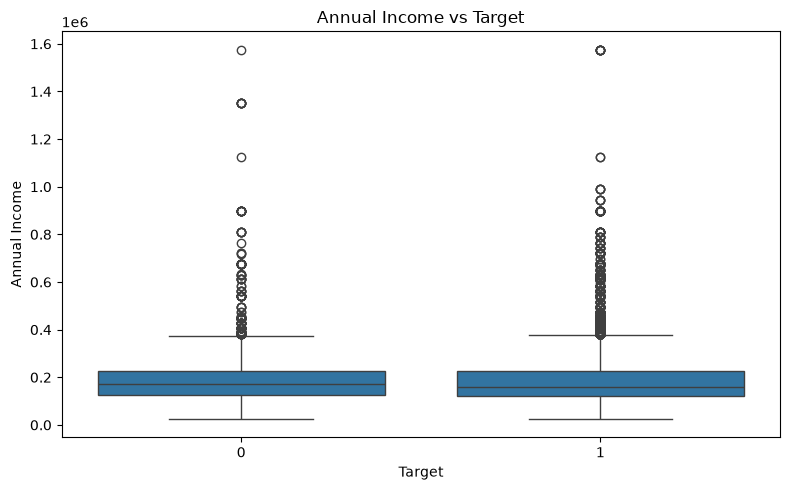

In [26]:
# Relationship between annual income and target

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="AMT_INCOME_TOTAL"
)

plt.title("Annual Income vs Target")
plt.xlabel("Target")
plt.ylabel("Annual Income")

plt.tight_layout()
plt.show()

## Feature Encoding

Machine learning models require numerical input. Therefore, categorical features are converted into numerical values using **Label Encoding**.

In [27]:
# Display categorical columns

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
categorical_columns

Categorical Columns:


Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='str')

In [28]:
# Encode categorical features

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

In [29]:
for column, encoder in label_encoders.items():
    print("\n", column)

    for value, code in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    ):
        print(f"{value} -> {code}")


 CODE_GENDER
F -> 0
M -> 1

 FLAG_OWN_CAR
N -> 0
Y -> 1

 FLAG_OWN_REALTY
N -> 0
Y -> 1

 NAME_INCOME_TYPE
Commercial associate -> 0
Pensioner -> 1
State servant -> 2
Student -> 3
Working -> 4

 NAME_EDUCATION_TYPE
Academic degree -> 0
Higher education -> 1
Incomplete higher -> 2
Lower secondary -> 3
Secondary / secondary special -> 4

 NAME_FAMILY_STATUS
Civil marriage -> 0
Married -> 1
Separated -> 2
Single / not married -> 3
Widow -> 4

 NAME_HOUSING_TYPE
Co-op apartment -> 0
House / apartment -> 1
Municipal apartment -> 2
Office apartment -> 3
Rented apartment -> 4
With parents -> 5

 OCCUPATION_TYPE
Accountants -> 0
Cleaning staff -> 1
Cooking staff -> 2
Core staff -> 3
Drivers -> 4
HR staff -> 5
High skill tech staff -> 6
IT staff -> 7
Laborers -> 8
Low-skill Laborers -> 9
Managers -> 10
Medicine staff -> 11
Private service staff -> 12
Realty agents -> 13
Sales staff -> 14
Secretaries -> 15
Security staff -> 16
Unknown -> 17
Waiters/barmen staff -> 18


In [31]:
# Display the encoded dataset

df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,1,1,1,0,427500.0,4,1,0,4,-12005,-4542,1,1,0,0,17,2.0,0
1,1,1,1,0,427500.0,4,1,0,4,-12005,-4542,1,1,0,0,17,2.0,0
2,1,1,1,0,112500.0,4,4,1,1,-21474,-1134,1,0,0,0,16,2.0,1
3,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,1
4,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,1


In [32]:
# Verify that all categorical columns have been encoded

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  int64  
 1   FLAG_OWN_CAR         36457 non-null  int64  
 2   FLAG_OWN_REALTY      36457 non-null  int64  
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  int64  
 6   NAME_EDUCATION_TYPE  36457 non-null  int64  
 7   NAME_FAMILY_STATUS   36457 non-null  int64  
 8   NAME_HOUSING_TYPE    36457 non-null  int64  
 9   DAYS_BIRTH           36457 non-null  int64  
 10  DAYS_EMPLOYED        36457 non-null  int64  
 11  FLAG_MOBIL           36457 non-null  int64  
 12  FLAG_WORK_PHONE      36457 non-null  int64  
 13  FLAG_PHONE           36457 non-null  int64  
 14  FLAG_EMAIL           36457 non-null  int64  
 15  OCCUPATION_TYPE      36457 non-null  int64  
 1

## Feature Selection

The input features (`X`) and target variable (`y`) are separated to prepare the dataset for machine learning model training.

In [33]:
# Separate input features and target variable

X = df.drop("TARGET", axis=1)

y = df["TARGET"]

In [34]:
# Display all input features

pd.DataFrame({
    "Feature Name": X.columns
})

,Feature Name
0,CODE_GENDER
1,FLAG_OWN_CAR
2,FLAG_OWN_REALTY
3,CNT_CHILDREN
4,AMT_INCOME_TOTAL
5,NAME_INCOME_TYPE
6,NAME_EDUCATION_TYPE
7,NAME_FAMILY_STATUS
8,NAME_HOUSING_TYPE
9,DAYS_BIRTH


In [35]:
# Display the shapes of features and target

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

Features Shape : (36457, 17)
Target Shape   : (36457,)


In [36]:
# Display the target class distribution

target_distribution = (
    y.value_counts()
     .rename_axis("Target")
     .reset_index(name="Count")
)

target_distribution

,Target,Count
0,1,32166
1,0,4291


**Observation**

The target variable remains imbalanced after preprocessing. Therefore, SMOTE was applied on the training data to balance the classes before training the Random Forest Classifier.

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the Random Forest Classifier model, while the testing set is used to evaluate its performance.

In [37]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
# Display the shapes of the training and testing datasets

split_summary = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [
        X_train.shape,
        X_test.shape,
        y_train.shape,
        y_test.shape
    ]
})

split_summary

,Dataset,Shape
0,X_train,"(29165, 17)"
1,X_test,"(7292, 17)"
2,y_train,"(29165,)"
3,y_test,"(7292,)"


## Model Training

A Random Forest Classifier is trained on the balanced dataset generated using SMOTE.

In [39]:
# ===========================
# Scale Numerical Features
# ===========================

X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()

numeric_cols = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS"
]

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ===========================
# Apply SMOTE ONLY on Training Data
# ===========================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# ===========================
# Train Random Forest
# ===========================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_smote, y_train_smote)

Before SMOTE:
TARGET
1    25732
0     3433
Name: count, dtype: int64

After SMOTE:
TARGET
1    25732
0    25732
Name: count, dtype: int64


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [40]:
# Predict the target values

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Model Evaluation

The trained Random Forest Classifier model is evaluated using standard classification metrics to measure its predictive performance.

In [41]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_metrics["Score"] = evaluation_metrics["Score"].round(4)

print(evaluation_metrics)

          Metric   Score
0       Accuracy  0.7505
1      Precision  0.9181
2         Recall  0.7875
3       F1-Score  0.8478
4  ROC-AUC Score  0.6812


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("\nModel Accuracy:")
print(round(model.score(X_test, y_test), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

TARGET Counts:
TARGET
1    32166
0     4291
Name: count, dtype: int64

TARGET Percentage:
TARGET
1    88.22997
0    11.77003
Name: proportion, dtype: float64

Model Accuracy:
0.7505

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.47      0.31       858
           1       0.92      0.79      0.85      6434

    accuracy                           0.75      7292
   macro avg       0.57      0.63      0.58      7292
weighted avg       0.84      0.75      0.78      7292


Confusion Matrix:
[[ 406  452]
 [1367 5067]]


In [43]:
# Generate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 406,  452],
       [1367, 5067]])

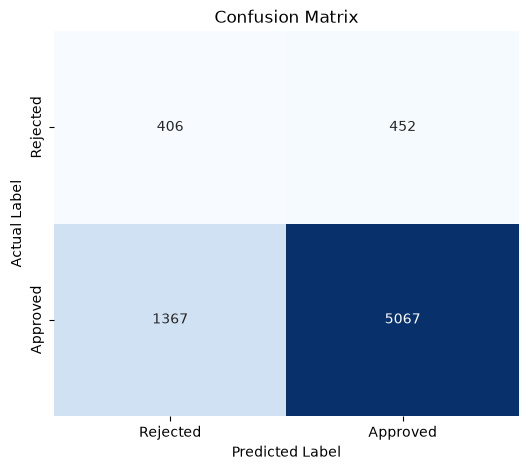

In [44]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [45]:
# Display the classification report

classification_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
).transpose()

classification_df.round(4)

,precision,recall,f1-score,support
0,0.2290,0.4732,0.3086,858.0000
1,0.9181,0.7875,0.8478,6434.0000
accuracy,0.7505,0.7505,0.7505,0.7505
macro avg,0.5735,0.6304,0.5782,7292.0000
weighted avg,0.8370,0.7505,0.7844,7292.0000


## Save the Trained Model

The trained Random Forest Classifier model is saved using the Joblib library. This allows the trained model to be reused later without retraining, particularly for deployment in the Flask web application.

In [46]:
# Save the trained model

joblib.dump(model, "../model/best_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

print("✅ Model saved successfully.")

✅ Model saved successfully.


## Load and Verify the Saved Model

The saved model is loaded from disk to verify that it has been stored correctly and is ready for deployment.

In [47]:
# Load the saved model

loaded_model = joblib.load("../model/best_model.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [48]:
# Verify the model type

type(loaded_model)

sklearn.ensemble._forest.RandomForestClassifier

## Sample Prediction

A sample prediction is performed using the trained model to verify that it can successfully classify a credit card application.

In [49]:
# Perform a sample prediction

prediction = loaded_model.predict(X_test.iloc[:1])[0]

status = "Approved" if prediction == 1 else "Rejected"

print(f"Sample Prediction: {status}")

Sample Prediction: Rejected


## Model Performance Summary

The Random Forest Classifier model was successfully trained and evaluated using multiple classification metrics, including Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and Classification Report.

After evaluation, the trained model was saved using the Joblib library and successfully reloaded to verify its integrity. A sample prediction further confirmed that the saved model is ready for deployment within the Flask web application.

## Conclusion

A Random Forest Classifier was successfully developed to predict credit card approval using customer demographic and financial information. The dataset was preprocessed through data cleaning, label encoding, feature scaling, and SMOTE-based class balancing. The trained model achieved good predictive performance while effectively handling class imbalance and was successfully integrated into a Flask web application for real-time credit card eligibility prediction.

## Future Scope

The project can be further improved by:

- Implementing advanced ensemble models such as XGBoost or LightGBM for higher predictive accuracy.
- Integrating additional financial features such as credit score and banking transaction history.
- Deploying the application on a cloud platform for public access.
- Incorporating Explainable AI (XAI) techniques to provide transparent prediction results.